In [ ]:
# install dependencies
%pip install simpy numpy pandas matplotlib

In [28]:
import simpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [29]:
class BankSimulation:
    """
    Bank simulation with:
    - Arrival rate: 45 customers/hour = 0.75 customers/min
    - 50% go to ATM first, 50% go directly to cashiers
    - ATM service time: Triangular(1, 4, 2) minutes
    - Cashier service time: Triangular(3, 20, 5) minutes
    - After ATM: 30% proceed to cashier, 70% exit
    - 5 cashiers (single shared queue), 1 ATM
    """

    def __init__(self, sim_time, num_cashiers=5,
                 atm_low=1, atm_high=4, atm_mode=2,
                 cashier_low=3, cashier_high=20, cashier_mode=5,
                 arrival_rate=0.75, seed=42):
        self.sim_time = sim_time
        self.num_cashiers = num_cashiers
        self.atm_low = atm_low
        self.atm_high = atm_high
        self.atm_mode = atm_mode
        self.cashier_low = cashier_low
        self.cashier_high = cashier_high
        self.cashier_mode = cashier_mode
        self.arrival_rate = arrival_rate

        np.random.seed(seed)

        # SimPy environment & resources
        self.env = simpy.Environment()
        self.atm = simpy.Resource(self.env, capacity=1)
        self.cashiers = simpy.Resource(self.env, capacity=num_cashiers)

        # Tracking metrics
        self.time_in_bank = []          # total sojourn time per customer
        self.cashier_busy_time = 0.0    # accumulated busy time across all cashier slots

        # Queue-length snapshots (sampled every minute)
        self.snap_time = []
        self.snap_atm_queue = []
        self.snap_cashier_queue = []

    # ------------------------------------------------------------------
    def _atm_service_time(self):
        return np.random.triangular(self.atm_low, self.atm_mode, self.atm_high)

    def _cashier_service_time(self):
        return np.random.triangular(self.cashier_low, self.cashier_mode, self.cashier_high)

    # ------------------------------------------------------------------
    def monitor(self):
        """Sample queue lengths every minute throughout the simulation."""
        while True:
            self.snap_time.append(self.env.now)
            self.snap_atm_queue.append(len(self.atm.queue))
            self.snap_cashier_queue.append(len(self.cashiers.queue))
            yield self.env.timeout(1)

    # ------------------------------------------------------------------
    def customer(self, arrival_time):
        """Simulate one customer's path through the bank."""
        goes_to_atm_first = np.random.rand() < 0.5

        if goes_to_atm_first:
            # --- ATM path ---
            with self.atm.request() as req:
                yield req
                yield self.env.timeout(self._atm_service_time())

            # 30% proceed to cashier after ATM
            if np.random.rand() < 0.30:
                yield from self._see_cashier()
            # else exit immediately
        else:
            # --- Direct-to-cashier path ---
            yield from self._see_cashier()

        # Record total time spent in the bank
        self.time_in_bank.append(self.env.now - arrival_time)

    def _see_cashier(self):
        """Request a cashier and receive service (always exits afterwards)."""
        with self.cashiers.request() as req:
            yield req
            service_time = self._cashier_service_time()
            self.cashier_busy_time += service_time
            yield self.env.timeout(service_time)

    # ------------------------------------------------------------------
    def gen_arrivals(self):
        """Poisson arrivals: exponential inter-arrival times."""
        while True:
            yield self.env.timeout(np.random.exponential(1 / self.arrival_rate))
            self.env.process(self.customer(self.env.now))

    # ------------------------------------------------------------------
    def simulate(self):
        self.env.process(self.monitor())
        self.env.process(self.gen_arrivals())
        self.env.run(until=self.sim_time)

    # ------------------------------------------------------------------
    def results(self):
        """Return a dict of summary metrics."""
        cashier_utilization = self.cashier_busy_time / (self.num_cashiers * self.sim_time)
        return {
            'cashier_utilization': cashier_utilization,
            'mean_cashier_queue': np.mean(self.snap_cashier_queue),
            'mean_atm_queue': np.mean(self.snap_atm_queue),
            'mean_time_in_bank': np.mean(self.time_in_bank),
            'time_in_bank': self.time_in_bank,
        }

In [30]:
# ── Baseline: 5 cashiers, max cashier service = 20 min ────────────────
SIM_TIME = 100_000   # minutes  (~69 days — long enough for stable estimates)

base = BankSimulation(sim_time=SIM_TIME, num_cashiers=5, seed=0)
base.simulate()
res_base = base.results()

print("Baseline (5 cashiers, max 20 min service)")
print("")
print(f"  Cashier utilization         : {res_base['cashier_utilization']:.4f}")
print(f"  Mean queue length (cashiers): {res_base['mean_cashier_queue']:.4f}")
print(f"  Mean queue length (ATM)     : {res_base['mean_atm_queue']:.4f}")
print(f"  Mean time in bank           : {res_base['mean_time_in_bank']:.4f} min")

Baseline (5 cashiers, max 20 min service)

  Cashier utilization         : 0.9151
  Mean queue length (cashiers): 5.1261
  Mean queue length (ATM)     : 3.0725
  Mean time in bank           : 18.1834 min


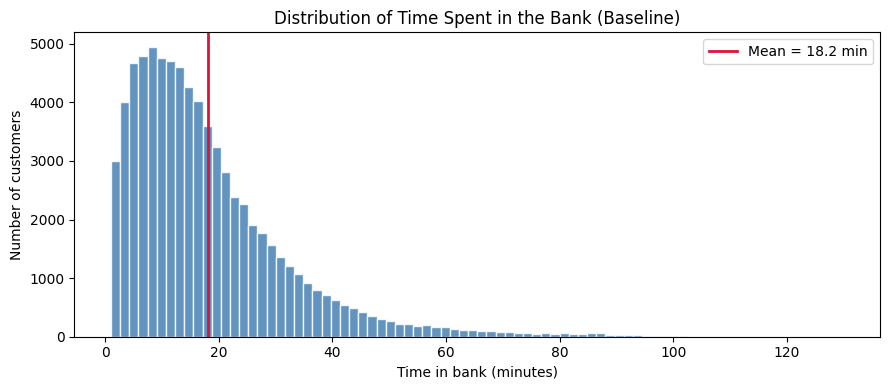

In [31]:
# ── Distribution of time spent in the bank (baseline) ─────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(res_base['time_in_bank'], bins=80, edgecolor='white', color='steelblue', alpha=0.85)
ax.axvline(res_base['mean_time_in_bank'], color='crimson', lw=2,
           label=f"Mean = {res_base['mean_time_in_bank']:.1f} min")
ax.set_xlabel('Time in bank (minutes)')
ax.set_ylabel('Number of customers')
ax.set_title('Distribution of Time Spent in the Bank (Baseline)')
ax.legend()
plt.tight_layout()
plt.savefig('bank_time_distribution_baseline.png', dpi=150)
plt.show()

In [32]:
# ── Scenario A: 6 cashiers, same service distribution ─────────────────
scen_a = BankSimulation(sim_time=SIM_TIME, num_cashiers=6, seed=0)
scen_a.simulate()
res_a = scen_a.results()

print("Scenario A: 6 cashiers (max 20 min service)")
print("")
print(f"  Cashier utilization         : {res_a['cashier_utilization']:.4f}")
print(f"  Mean queue length (cashiers): {res_a['mean_cashier_queue']:.4f}")
print(f"  Mean queue length (ATM)     : {res_a['mean_atm_queue']:.4f}")
print(f"  Mean time in bank           : {res_a['mean_time_in_bank']:.4f} min")

Scenario A: 6 cashiers (max 20 min service)

  Cashier utilization         : 0.7609
  Mean queue length (cashiers): 0.8906
  Mean queue length (ATM)     : 2.9659
  Mean time in bank           : 12.3752 min


In [33]:
# ── Scenario B: 5 cashiers, max service time = 10 min ─────────────────
scen_b = BankSimulation(sim_time=SIM_TIME, num_cashiers=5,
                        cashier_low=3, cashier_high=10, cashier_mode=5, seed=0)
scen_b.simulate()
res_b = scen_b.results()

print("Scenario B: 5 cashiers (max 10 min service)")
print("")
print(f"  Cashier utilization         : {res_b['cashier_utilization']:.4f}")
print(f"  Mean queue length (cashiers): {res_b['mean_cashier_queue']:.4f}")
print(f"  Mean queue length (ATM)     : {res_b['mean_atm_queue']:.4f}")
print(f"  Mean time in bank           : {res_b['mean_time_in_bank']:.4f} min")

Scenario B: 5 cashiers (max 10 min service)

  Cashier utilization         : 0.5823
  Mean queue length (cashiers): 0.1689
  Mean queue length (ATM)     : 3.0246
  Mean time in bank           : 9.3316 min


                                     Cashier utilization  Mean cashier queue length  Mean time in bank (min)
Baseline   (5 cashiers, max 20 min)               0.9151                     5.1261                  18.1834
Scenario A (6 cashiers)                           0.7609                     0.8906                  12.3752
Scenario B (5 cashiers, max 10 min)               0.5823                     0.1689                   9.3316


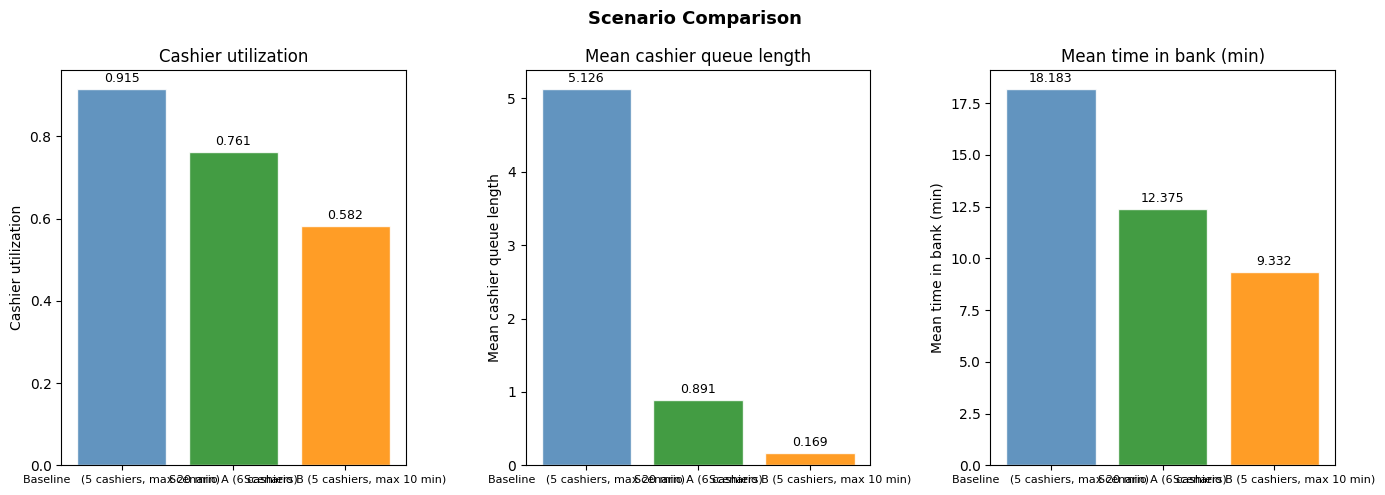

In [34]:
# ── Side-by-side comparison ────────────────────────────────────────────
labels = ['Baseline   (5 cashiers, max 20 min)', 'Scenario A (6 cashiers)', 'Scenario B (5 cashiers, max 10 min)']
metrics = {
    'Cashier utilization': [res_base['cashier_utilization'], res_a['cashier_utilization'], res_b['cashier_utilization']],
    'Mean cashier queue length': [res_base['mean_cashier_queue'], res_a['mean_cashier_queue'], res_b['mean_cashier_queue']],
    'Mean time in bank (min)': [res_base['mean_time_in_bank'], res_a['mean_time_in_bank'], res_b['mean_time_in_bank']],
}

df = pd.DataFrame(metrics, index=labels)
print(df.to_string(float_format='{:.4f}'.format))

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['steelblue', 'forestgreen', 'darkorange']

for ax, (metric, values) in zip(axes, metrics.items()):
    bars = ax.bar(labels, values, color=colors, edgecolor='white', alpha=0.85)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=9)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)

plt.suptitle('Scenario Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bank_scenario_comparison.png', dpi=150)
plt.show()